In [1]:
# import libraries for reading data
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageOps
import cv2
import re
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models
import ast
from torchvision.models import swin_b, Swin_B_Weights
import torch.nn as nn
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from concurrent.futures import ProcessPoolExecutor
from PIL import ImageEnhance, Image
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from concurrent.futures import ThreadPoolExecutor
import torch.multiprocessing as mp
from torch.utils.data import WeightedRandomSampler
import torch.nn.functional as F
from sklearn.metrics import f1_score
import gc
mp.set_sharing_strategy('file_system')

<jemalloc>: Unsupported system page size


In [2]:
gc.collect()
torch.cuda.empty_cache()

### Einlesen der Daten und Übersicht über die Daten

In [3]:
# data paths
train1_images_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_images_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_images_path = "/datasets/multi-view-pig-posture-recognition/test_images"

# csv path with row_id, image_id, width, height, bbox, class_id
train1_csv_path = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv_path = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv_path = "/datasets/multi-view-pig-posture-recognition/test.csv"

# txt file path
pig_posture_txt = "/datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt"

In [4]:
# read all files and show statistics and content of csv files, column names etc.
# read csv files
train1_df = pd.read_csv(train1_csv_path)
train2_df = pd.read_csv(train2_csv_path)
test_df = pd.read_csv(test_csv_path)


In [5]:
def extract_pen_id(s: str):
    m = re.search(r'^(pen\d+)', s)
    return m.group(1) if m else None

def extract_camera_type(s: str):
    m = re.search(r'_(orb|tur)_', s)
    return m.group(1) if m else None

def extract_camera_number(s: str):
    m = re.search(r'cam(\d+)', s)
    return m.group(1) if m else None

# df1 = train1.csv als DataFrame; ersetze 'FILENAME_COL' durch deine Spalte (z. B. 'image', 'file_name', ...).
FILENAME_COL = "image_id"
train1_df["pen_id"]        = train1_df[FILENAME_COL].apply(extract_pen_id)
train1_df["camera_type"]   = train1_df[FILENAME_COL].apply(extract_camera_type)
train1_df["camera_number"] = train1_df[FILENAME_COL].apply(extract_camera_number)
train1_df["camera_view_id"]      = train1_df["pen_id"] + "_" + train1_df["camera_type"] + "_cam" + train1_df["camera_number"]


In [6]:
train1_df_distribution = train1_df['class_id'].value_counts().sort_index()
train2_df_distribution = train2_df['class_id'].value_counts().sort_index()

### Trennung der Kameras anhand der Bildnamen nur in Train2

In [7]:
train2_df["pen_id"]        = train2_df["image_id"].apply(extract_pen_id)
train2_df["camera_type"]   = train2_df["image_id"].apply(extract_camera_type)
train2_df["camera_number"] = train2_df["image_id"].apply(extract_camera_number)
train2_df["camera_view_id"]      = train2_df["pen_id"] + "_" + train2_df["camera_type"] + "_cam" + train2_df["camera_number"]


In [8]:
# transforms for data augmentation and data preprocessing
img_size = (384, 384) # größer als 224x224, damit der Backbone mehr Details sieht, aber nicht zu groß, um VRAM zu überlasten.
normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]


train_transforms = transforms.Compose([
    # HINWEIS: transforms.Resize(img_size) habe ich hier entfernt, 
    # da wir das Resize auf 384x384 nach dem Padding bereits direkt im Dataset machen!
    
    transforms.RandomHorizontalFlip(p=0.5),
    # RandomVerticalFlip entfernt – Schweine kleben nicht an der Decke!
    
    # NEU: Realistische Perspektiv-Verzerrung simuliert leicht abweichende Kamerastandorte
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    
    # Rotation drastisch reduziert (von 15 auf 5 Grad)
    transforms.RandomRotation(degrees=5), 
    
    # Affine Transformationen entfernt (Perspektive übernimmt das jetzt sauberer)
    
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    
    transforms.ToTensor(),
    
    # OPTIMIERT: RandomErasing simuliert Verdeckungen durch Gitter oder andere Schweine.
    # Scale angepasst, damit nicht versehentlich das komplette Schwein gelöscht wird.
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])

# Die val_transforms bleiben sauber und ohne Verzerrungen:
val_transforms = transforms.Compose([
    # Auch hier kein Resize mehr nötig, da es im Dataset passiert
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])


### Anmerkung 09.03.26 : Neue train_transforms-Inhalte und Ideen.
Der Gedanke dahinter: Die Kameras hängen in den Ställen meist schräg von oben. Wenn wir das Bild vertikal spiegeln (Schweine an der Decke) oder um 15 Grad rotieren, zwingen wir das Modell, physikalisch unmögliche Posen zu lernen. Stattdessen nutzen wir RandomPerspective, um verschiedene Kamerawinkel im Raum zu simulieren, und optimieren das RandomErasing, um Gitterstäbe und verdeckende Nachbarschweine besser nachzuahmen.

In [9]:
class PigCropDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, preload=True):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        if preload:
            print(f"Lade {len(self.df)} Bilder mit 120 Cores in den RAM...")
            
            def load_single_image(idx):
                r = self.df.iloc[idx]
                p = os.path.join(self.image_dir, r["image_id"])
                img = Image.open(p).convert("RGB")
    
                bbox = ast.literal_eval(r["bbox"]) if isinstance(r["bbox"], str) else r["bbox"]
                x, y, w, h = bbox
    
                # 1. Intelligentes Crop-Padding: Wir suchen das Zentrum des Schweins
                center_x = x + w / 2.0
                center_y = y + h / 2.0
                
                # 2. Wir nehmen die längste Seite und geben 15% Kontext dazu
                side = max(w, h) * 1.15
                
                # 3. Neue quadratische Koordinaten berechnen
                x_min = int(center_x - side / 2.0)
                y_min = int(center_y - side / 2.0)
                x_max = int(center_x + side / 2.0)
                y_max = int(center_y + side / 2.0)
                
                # 4. Falls das Quadrat über den echten Bildrand ragt, padden wir das Originalbild
                pad_left = max(0, -x_min)
                pad_top = max(0, -y_min)
                pad_right = max(0, x_max - img.width)
                pad_bottom = max(0, y_max - img.height)
                
                if pad_left > 0 or pad_top > 0 or pad_right > 0 or pad_bottom > 0:
                    img = ImageOps.expand(img, border=(pad_left, pad_top, pad_right, pad_bottom), fill=0)
                    # Koordinaten auf das gepaddete Bild anpassen
                    x_min += pad_left
                    y_min += pad_top
                    x_max += pad_left
                    y_max += pad_top
    
                # 5. Ausschneiden (jetzt immer perfekt quadratisch und meistens nur echter Hintergrund!)
                crop = img.crop((x_min, y_min, x_max, y_max))
                crop = crop.resize((384, 384), Image.BILINEAR)
                
                return crop, int(r["class_id"])

            with ThreadPoolExecutor(max_workers=120) as executor:
                results = list(tqdm(executor.map(load_single_image, range(len(self.df))), total=len(self.df)))

            self.images, self.labels = zip(*results)
            print("Preloading abgeschlossen. Alle Bilder liegen im RAM.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Kein Disk-Zugriff mehr! Nur noch RAM-Zugriff.
        img = self.images[idx]
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, torch.tensor(label, dtype=torch.long)


In [10]:
sampleDS = PigCropDataset(train2_df, train2_images_path, transform=train_transforms)
loader = DataLoader(sampleDS, batch_size=9, shuffle=True)
for x, y in loader:
    print("Batch Image Shape:", x.shape)  # erwartet: [9, 3, 224, 224]
    print("Batch Label Shape:", y.shape)  # erwartet: [9]
    print("First Label:", y[0].item())    # 0..4
    break


Lade 23450 Bilder mit 120 Cores in den RAM...


100%|██████████| 23450/23450 [00:02<00:00, 8318.41it/s] 


Preloading abgeschlossen. Alle Bilder liegen im RAM.
Batch Image Shape: torch.Size([9, 3, 384, 384])
Batch Label Shape: torch.Size([9])
First Label: 1


In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  # Nutze die ersten 4 GPUs (0-3) für Training


class PigPostureCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(PigPostureCNN, self).__init__()
        
        weights = Swin_B_Weights.DEFAULT
        original_model = swin_b(weights=weights)
        
        self.backbone = original_model.features
        self.norm = original_model.norm           # LayerNorm – bleibt
        self.pool = nn.AdaptiveAvgPool2d(1)       # NEU: Eigenes Pooling
        
        # Swin-Base hat 1024 Features
        in_features = 1024
        
        self.label_classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)        # Output: (B, H, W, C)
        x = self.norm(x)            # LayerNorm
        x = x.permute(0, 3, 1, 2)  # NEU: (B, H, W, C) → (B, C, H, W) – als Tensor-Op
        x = self.pool(x)            # NEU: (B, C, 1, 1)
        x = torch.flatten(x, 1)    # NEU: (B, C) – als Tensor-Op
        label_preds = self.label_classifier(x)
        return label_preds
        
# Instanziierung für alle verfügbaren GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PigPostureCNN(num_classes=5)

# Multi-GPU Parallelisierung aktivieren
if torch.cuda.device_count() > 1:
    print(f"Nutze {torch.cuda.device_count()} GPUs für das Training!")
    model = nn.DataParallel(model)

model = model.to(device)

Nutze 4 GPUs für das Training!


In [13]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # ce_loss berechnen (inkl. Label Smoothing und Gewichte)
        ce_loss = F.cross_entropy(
            inputs, targets, 
            weight=self.weight, 
            label_smoothing=self.label_smoothing, 
            reduction='none'
        )
        pt = torch.exp(-ce_loss) 
        # Formel: (1-pt)^gamma * ce_loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [14]:
class Learner:
    def __init__(self, model, train_dl, val_dl, device=None, class_weights=None):
        self.model = model
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.device = device if device else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        self.model = self.model.to(self.device)
        
        # === Gewichtete Loss-Funktion MIT Label Smoothing (aus deinem Code) ===
        ws = class_weights.to(self.device) if class_weights is not None else None
        self.loss_fn_classifier = FocalLoss(weight=ws, gamma=2.0, label_smoothing=0.1)
        
        if ws is not None:
            print(f"✅ Focal Loss mit Gewichten aktiv für {len(class_weights)} Klassen")

        self.best_f1 = 0.0 # Geändert von best_acc auf best_f1
        self.best_model_state = None
        self.scaler = torch.cuda.amp.GradScaler() # Aus deinem Code für AMP
        
        # Initially freeze backbone
        self.freeze()
        
    def freeze(self):
        """Freeze backbone parameters"""
        actual_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        for param in actual_model.backbone.parameters():
            param.requires_grad = False
        print("Backbone frozen")
        
    def unfreeze(self):
        """Unfreeze backbone parameters"""
        actual_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        for param in actual_model.backbone.parameters():
            param.requires_grad = True
        print("Backbone unfrozen")

    def calc_losses(self, label_preds, yb):
        """Calculate loss for classification"""
        # Angepasst: Nur noch Classification Loss, keine BBox-Losses mehr
        classification_loss = self.loss_fn_classifier(label_preds, yb)
        return classification_loss

    # plot_batch und plot_val_samples habe ich entfernt, da sie BBox-Plotting machten, 
    # was für dein reines Klassifikationsproblem ohne vorhergesagte Boxen nicht passt.
        
    def fit(self, epochs, lr=1e-3, weight_decay=1e-3, use_onecycle=True, early_stopping_patience=5):
        """Train the model for specified epochs"""
        try:
            from training_monitor import TrainingMonitor
            use_monitor = True
        except ImportError:
            print("⚠️ training_monitor nicht gefunden. Lade ohne grafischen Monitor.")
            use_monitor = False
        
        # Setup optimizer
        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.model.parameters()), 
            lr=lr, weight_decay=weight_decay
        )
        
        # Setup scheduler
        if use_onecycle:
            self.scheduler = torch.optim.lr_scheduler.OneCycleLR(
                self.optimizer,
                max_lr=lr * 10,
                total_steps=epochs * len(self.train_dl),
                pct_start=0.3,
                anneal_strategy='cos',
                div_factor=25.0,
                final_div_factor=1e4
            )
        else:
            self.scheduler = None
        
        # Setup monitor
        if use_monitor:
            monitor = TrainingMonitor(epochs, plot_mode="separate", zoom=True, row_height=1.5)
        
        patience_counter = 0

        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0.0
            
            # tqdm aus deinem Code übernommen für die CLI-Ansicht
            for xb, yb in tqdm(self.train_dl, desc=f"Epoch {epoch+1}/{epochs}"):
                xb = xb.to(self.device, non_blocking=True)
                yb = yb.to(self.device, non_blocking=True)
                
                self.optimizer.zero_grad()
                
                # AMP aus deinem Code übernommen
                with torch.cuda.amp.autocast():
                    label_preds = self.model(xb)
                    loss = self.calc_losses(label_preds, yb)
                
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
                
                if self.scheduler:
                    self.scheduler.step()
                    
                train_loss += loss.item() * xb.size(0)
            
            train_loss = train_loss / len(self.train_dl.dataset)
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            all_preds = []
            all_targets = []

            with torch.no_grad():
                for xb, yb in self.val_dl:
                    xb = xb.to(self.device, non_blocking=True)
                    yb = yb.to(self.device, non_blocking=True)
                    
                    with torch.cuda.amp.autocast():
                        label_preds = self.model(xb)
                        loss = self.calc_losses(label_preds, yb)

                    val_loss += loss.item() * xb.size(0)
                    
                    # Für F1-Score sammeln (aus deinem Code)
                    all_preds.extend(label_preds.argmax(1).cpu().numpy())
                    all_targets.extend(yb.cpu().numpy())
            
            val_loss = val_loss / len(self.val_dl.dataset)
            val_f1 = f1_score(all_targets, all_preds, average='macro')
            
            print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f}")
            
            # Early Stopping Check (angepasst von best_acc auf best_f1)
            if val_f1 > self.best_f1:
                self.best_f1 = val_f1
                patience_counter = 0
                self.best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                print(f"  ✅ Neues bestes Modell gespeichert (Val Macro F1: {val_f1:.4f})")
            else:
                patience_counter += 1
                print(f"  ⚠️ Keine Verbesserung seit {patience_counter}/{early_stopping_patience} Epochen")
            
            # Update monitor
            if use_monitor:
                metrics = {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'val_macro_f1': val_f1 # Name geändert, damit der Monitor weiß, was es ist
                }
                if self.scheduler:
                    metrics['lr'] = self.scheduler.get_last_lr()[0]
                    
                monitor.update(metrics)
                
            if patience_counter >= early_stopping_patience:
                print(f"  🛑 Early Stopping nach Epoche {epoch+1}!")
                break
        
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"Training completed. Best validation F1: {self.best_f1:.4f}")
            
        return self.best_f1

In [15]:
# GroupShuffleSplit nach image_id: Alle Schweine aus einem Bild bleiben zusammen,
# aber verschiedene Bilder der GLEICHEN Kamera können in Train UND Val sein.
# Das verhindert Data Leakage auf Bild-Ebene, gibt aber trotzdem einen sauberen 80/20 Split.
# Erstelle eine frame_id, die synchrone Aufnahmen der verschiedenen Kameras bündelt
train2_df['frame_id'] = train2_df['image_id'].apply(lambda x: re.sub(r'_cam\d+', '', x))
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(train2_df, groups=train2_df['frame_id']))

train_data = train2_df.iloc[train_idx].copy()
val_data = train2_df.iloc[val_idx].copy()

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Train Kameras: {train_data['camera_view_id'].nunique()}")
print(f"Val Kameras: {val_data['camera_view_id'].nunique()}")

Training samples: 18745
Validation samples: 4705
Train Kameras: 8
Val Kameras: 8


In [16]:
# === Klassen-Gewichte berechnen (inverse Häufigkeit) ===
class_counts = train_data['class_id'].value_counts().sort_index()
total = len(train_data)
class_weights = torch.tensor(
    total / (len(class_counts) * class_counts.values), 
    dtype=torch.float32
)
print(f"Klassen-Gewichte: {class_weights}")

# KEIN WeightedRandomSampler mehr! Die Gewichtung passiert nur im Loss.

Klassen-Gewichte: tensor([1.5333, 1.3743, 6.8537, 0.4685, 0.7464])


In [17]:
torch.cuda.empty_cache()

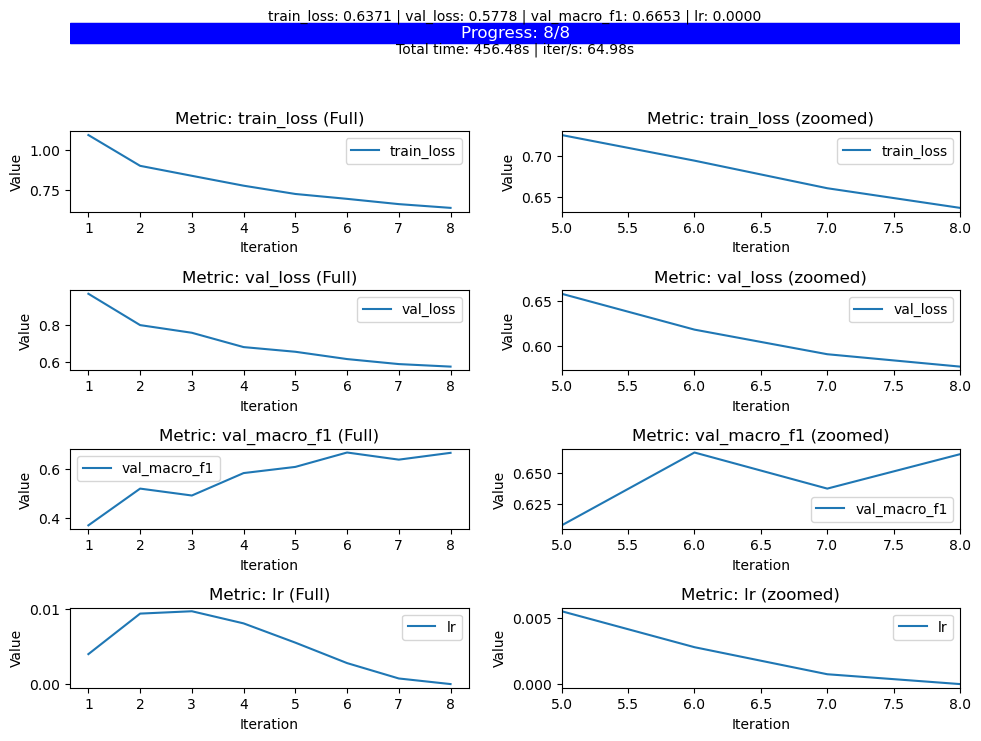

Training completed. Best validation F1: 0.6667


0.6666998955639192

In [18]:
# --- VORBEREITUNG ---
# Nutze hier die Version von PigCropDataset, in die wir das Caching (RAM-Speicher) 
# eingebaut haben, damit es ab Epoche 2 extrem schnell geht.
train_ds = PigCropDataset(train_data, train2_images_path, transform=train_transforms)
val_ds = PigCropDataset(val_data, train2_images_path, transform=val_transforms)

batch_size = 256 # Reduzierung batchsize bei neuem Img_size

train_dl = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=8,               # 8 Worker sind stabil und schnell genug für RAM-Daten
    pin_memory=True,             # Schaufelt Daten schneller in den VRAM
    prefetch_factor=2, 
    persistent_workers=True
)

val_dl = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True,
    persistent_workers=True
)
# 1. Modell & Learner vorbereiten (wie bisher)

learner = Learner(model, train_dl, val_dl, device=device, class_weights=class_weights)

# --- PHASE 1: Classifier-Training (Frozen Backbone) ---
# Wir geben dem Kopf 15 Epochen, um sich an die Features zu gewöhnen
print("Starte Phase 1: Classifier Fine-Tuning...")
learner.freeze()
learner.fit(epochs=8, lr=1e-3, early_stopping_patience=5)

In [19]:
gc.collect()
torch.cuda.empty_cache()

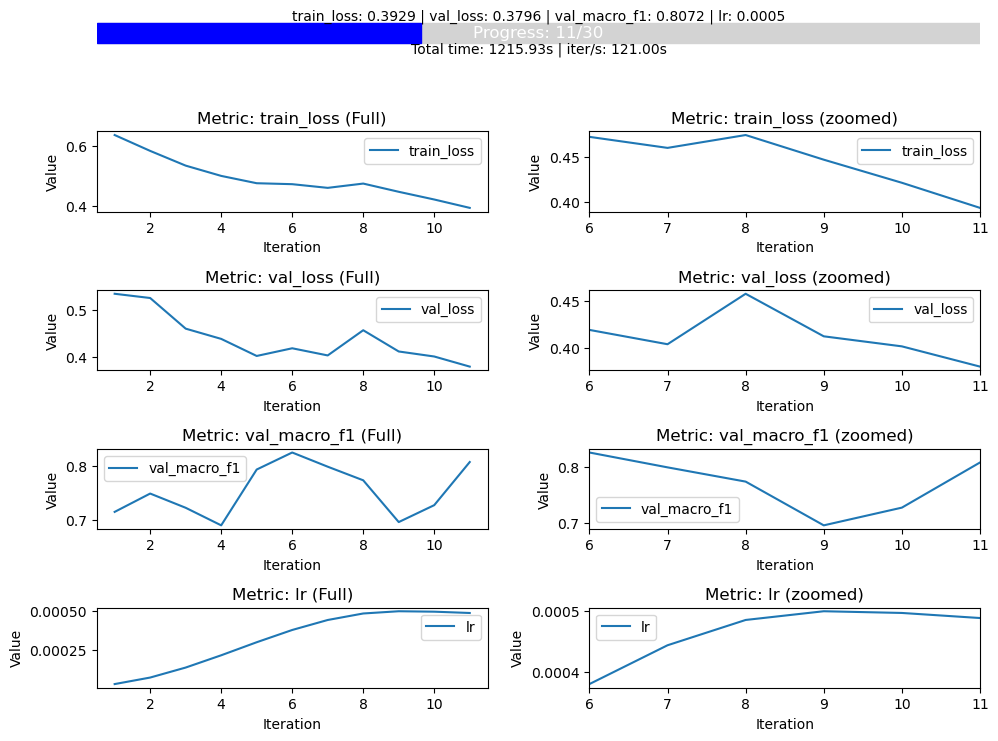

  🛑 Early Stopping nach Epoche 11!
Training completed. Best validation F1: 0.8248


0.8248424450349265

In [20]:
batch_size_phase2 = 96 # Reduzierung batchsize bei neuem Img_size

train_dl = DataLoader(train_ds, batch_size=batch_size_phase2, shuffle=True,
                      num_workers=16, pin_memory=True, persistent_workers=True)
val_dl = DataLoader(val_ds, batch_size=batch_size_phase2, shuffle=False,
                    num_workers=8, pin_memory=True, persistent_workers=True)

learner.train_dl = train_dl
learner.val_dl = val_dl

# --- PHASE 2: Alles offen, niedrige LR ---
print("Starte Phase 2: Full Model Fine-Tuning...")
learner.unfreeze()
learner.fit(epochs=30, lr=5e-5, early_stopping_patience=5)

In [21]:
# 1. Alte Datasets und DataLoader löschen
try:
    del sampleDS, loader
except: pass
try:
    del train_ds, val_ds, train_dl, val_dl
except: pass
gc.collect()
torch.cuda.empty_cache()

# 2. /dev/shm aufräumen (hier liegen die 8 GB!)
os.system("rm -rf /dev/shm/* 2>/dev/null")
# Kontrolle: Jetzt sollte /dev/shm fast leer sein
os.system("df -h /dev/shm")

Filesystem      Size  Used Avail Use% Mounted on
shm             8.0G   26M  8.0G   1% /dev/shm


0

In [22]:
# 1. Test-Daten vorbereiten
test_df_copy = test_df.copy()
test_df_copy['class_id'] = 0 

# Sicherheitshalber eine moderate Batch-Size wählen (z.B. 512 oder 256)
batch_size_inference = 512 

test_ds = PigCropDataset(test_df_copy, test_images_path, transform=val_transforms)
test_dl = DataLoader(test_ds, batch_size=batch_size_inference, shuffle=False, 
                    num_workers=0, pin_memory=True)

# 2. Modell in den Vorhersage-Modus schalten
model.eval()
all_predictions = []
print(f"Erstelle Vorhersagen mit TTA auf {device}...")

with torch.no_grad():
    with torch.cuda.amp.autocast():
        for xb, _ in tqdm(test_dl):
            xb = xb.to(device, non_blocking=True)
            
            # 1. Vorhersage Original
            out1 = model(xb)
            
            # 2. Vorhersage Horizontal gespiegelt (TTA)
            out2 = model(torch.flip(xb, dims=[3]))
            
            # Durchschnitt der Wahrscheinlichkeiten (Softmax) bilden
            prob1 = torch.softmax(out1, dim=1)
            prob2 = torch.softmax(out2, dim=1)
            avg_probs = (prob1 + prob2) / 2
            
            all_predictions.extend(avg_probs.argmax(1).cpu().numpy())

# 3. Die finale CSV-Datei erstellen
submission = pd.DataFrame({
    'row_id': test_df['row_id'],
    'class_id': all_predictions
})

# Speichern
submission_name = '8th_submission.csv'
submission.to_csv(submission_name, index=False)

print(f"Erfolgreich! Die Datei '{submission_name}' mit {len(submission)} Zeilen wurde erstellt.")

Lade 11708 Bilder mit 120 Cores in den RAM...


100%|██████████| 11708/11708 [00:00<00:00, 54415.23it/s] 


Preloading abgeschlossen. Alle Bilder liegen im RAM.
Erstelle Vorhersagen mit TTA auf cuda...


100%|██████████| 23/23 [01:07<00:00,  2.92s/it]

Erfolgreich! Die Datei '8th_submission.csv' mit 11708 Zeilen wurde erstellt.
